# Analytic Task — UEFA Possession

**HIT140 Assessment 2 · Darwin Group 26 · Peng Song**

---

## 1. Analytic question

> **Is the mean possession percentage of UEFA teams at the FIFA World Cup 2026 different from 50%?**

I chose possession because it is easy to explain and it is available for every team-match row in the shared dataset. The reference value of **50%** represents an even share of possession in a simple two-team interpretation.

The main method is a **one-sample t-test**. I also check the assumptions and run alternative analyses because the same UEFA team can appear in several matches, and FIFA reports a separate “in contest” possession value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 60)
plt.rcParams['figure.dpi'] = 110

ALPHA = 0.05
TEST_VALUE = 50


---

## 2. Data sources and preparation

The analysis uses the group file `data/clean/team_match.csv`. It has one row for each team in each match (104 matches × 2 teams = 208 rows).

I also created `data/clean/team_confederation_lookup.csv`, a 48-team lookup table. It gives every team one football confederation and marks whether the team is from UEFA. This avoids typing a UEFA list directly into the test code and makes the classification easy to check.

In [2]:
df = pd.read_csv('../data/clean/team_match.csv')
lookup = pd.read_csv('../data/clean/team_confederation_lookup.csv')

print('team_match shape:', df.shape)
print('lookup shape    :', lookup.shape)
lookup.head(10)


team_match shape: (208, 55)
lookup shape    : (48, 4)


,team,confederation,region,is_uefa
0,Algeria,CAF,Africa,False
1,Argentina,CONMEBOL,South America,False
2,Australia,AFC,Asia,False
3,Austria,UEFA,Europe,True
4,Belgium,UEFA,Europe,True
5,Bosnia and Herzegovina,UEFA,Europe,True
6,Brazil,CONMEBOL,South America,False
7,Cabo Verde,CAF,Africa,False
8,Canada,CONCACAF,North/Central America & Caribbean,False
9,Colombia,CONMEBOL,South America,False


### 2.1 Data checks

Before testing the hypothesis, I check the row count, match count, missing values, duplicates and whether all 48 tournament teams are covered by the lookup table.

In [3]:
issues = []

if len(df) != 208:
    issues.append(f'Expected 208 team-match rows, found {len(df)}')
if df['match_id'].nunique() != 104:
    issues.append(f"Expected 104 matches, found {df['match_id'].nunique()}")
if not (df.groupby('match_id').size() == 2).all():
    issues.append('Some matches do not have exactly two team rows')
if df.duplicated(['match_id', 'side']).any():
    issues.append('Duplicate match_id + side rows found')
if df['possession_pct'].isna().any():
    issues.append('Missing possession values found')
if lookup['team'].duplicated().any():
    issues.append('Duplicate teams found in lookup table')

source_teams = set(df['team'])
lookup_teams = set(lookup['team'])
if source_teams != lookup_teams:
    issues.append(f'Lookup mismatch. Missing={sorted(source_teams-lookup_teams)}, extra={sorted(lookup_teams-source_teams)}')

print('All integrity checks passed.' if not issues else '\n'.join(issues))
print('Tournament teams:', df['team'].nunique())
print('UEFA teams in lookup:', int(lookup['is_uefa'].sum()))


All integrity checks passed.
Tournament teams: 48
UEFA teams in lookup: 16


In [4]:
# Join the lookup to the shared match dataset.
merged = df.merge(lookup, on='team', how='left', validate='many_to_one')
uefa = merged.loc[merged['is_uefa'] == True].copy()

print('UEFA team-match rows:', len(uefa))
print('Distinct UEFA teams :', uefa['team'].nunique())
print()
print('Matches per UEFA team:')
print(uefa.groupby('team').size().sort_values().to_string())


UEFA team-match rows: 80
Distinct UEFA teams : 16

Matches per UEFA team:
team
Czechia                   3
Scotland                  3
Türkiye                   3
Austria                   4
Bosnia and Herzegovina    4
Croatia                   4
Germany                   4
Netherlands               4
Sweden                    4
Portugal                  5
Belgium                   6
Norway                    6
Switzerland               6
England                   8
France                    8
Spain                     8


### 2.2 A source-data issue I found

FIFA reports possession in three parts: one percentage for each team plus an “in contest” percentage. For almost every match these add to about 100% after rounding. Two source pages contain `100% in contest`, which makes the three-part total impossible.

I **do not change the main `possession_pct` values by hand**, because the task is based on the collected FIFA values. I flag the issue and avoid using those two abnormal “in contest” values in the adjusted sensitivity check later.

In [5]:
match_check = merged.groupby('match_id').agg(
    two_team_possession=('possession_pct', 'sum'),
    contested=('possession_contested_pct', 'first')
)
match_check['three_part_total'] = match_check['two_team_possession'] + match_check['contested']

unusual = match_check[(match_check['three_part_total'] < 98) | (match_check['three_part_total'] > 102)]
print('Matches outside 98-102% after including contested possession:')
print(unusual.to_string())


Matches outside 98-102% after including contested possession:
           two_team_possession  contested  three_part_total
match_id                                                   
400021444                 90.0      100.0             190.0
400021492                 93.0      100.0             193.0


---

## 3. Descriptive statistics

The sample for the main test contains every UEFA team-match observation in the tournament. This gives 80 observations from 16 UEFA teams.

In [6]:
poss = uefa['possession_pct'].dropna()

summary = pd.Series({
    'n': len(poss),
    'mean': poss.mean(),
    'median': poss.median(),
    'std': poss.std(ddof=1),
    'min': poss.min(),
    'q1': poss.quantile(0.25),
    'q3': poss.quantile(0.75),
    'max': poss.max()
})
summary.round(2)


n         80.00
mean      48.36
median    48.00
std       10.09
min       29.00
q1        41.00
q3        56.25
max       72.00
dtype: float64

In [7]:
plt.figure(figsize=(8, 4.5))
plt.hist(poss, bins=10, edgecolor='black', alpha=0.75)
plt.axvline(TEST_VALUE, linestyle='--', linewidth=1.5, label='Reference = 50%')
plt.axvline(poss.mean(), linestyle='-', linewidth=1.5, label=f'Sample mean = {poss.mean():.2f}%')
plt.xlabel('Possession (%)')
plt.ylabel('Frequency')
plt.title('UEFA team-match possession distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/possession_uefa_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 880x495 with 1 Axes>

The sample mean is below 50%, but the difference is small. The histogram is fairly balanced and there are no obvious extreme values.

---

## 4. Checking the assumptions of the one-sample t-test

For this task I check three main points: the variable is numeric, the distribution is not strongly non-normal, and the observations are reasonably independent.

In [8]:
# 4.1 Outlier check using the 1.5 x IQR rule
q1, q3 = poss.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = uefa[(uefa['possession_pct'] < lo) | (uefa['possession_pct'] > hi)]

print(f'IQR fence: [{lo:.2f}, {hi:.2f}]')
print('Outlying rows:', len(outliers))


IQR fence: [18.12, 79.12]
Outlying rows: 0


In [9]:
# 4.2 Normality check
w, shapiro_p = stats.shapiro(poss)
print(f'Shapiro-Wilk W = {w:.4f}, p = {shapiro_p:.4f}')
if shapiro_p > ALPHA:
    print('No evidence of a strong departure from normality.')
else:
    print('The distribution departs from normality; interpret the t-test more carefully.')


Shapiro-Wilk W = 0.9854, p = 0.4955
No evidence of a strong departure from normality.


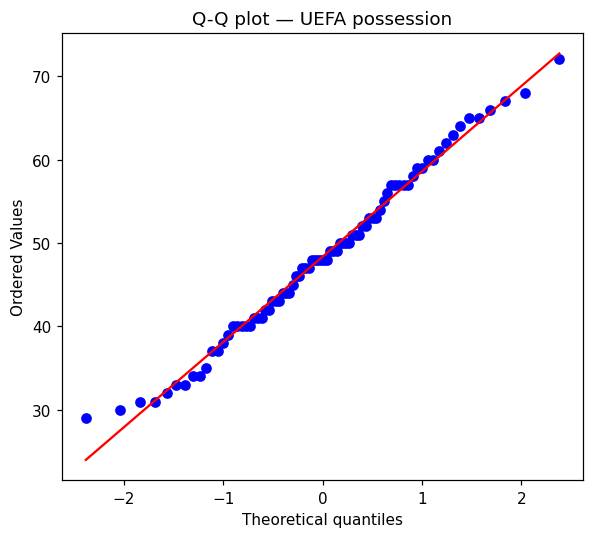

In [10]:
plt.figure(figsize=(5.5, 5))
stats.probplot(poss, dist='norm', plot=plt)
plt.title('Q-Q plot — UEFA possession')
plt.tight_layout()
plt.savefig('../figures/possession_uefa_qq.png', dpi=150, bbox_inches='tight')
plt.show()


### Independence limitation

The biggest assumption problem is independence. The 80 rows are not 80 completely unrelated teams: the same UEFA team appears in several matches. Match conditions can also link the two teams playing each other.

I keep the team-match test as the main analysis because that is the required one-sample t-test task, but I do **not** hide this limitation. In Section 6 I repeat the test after reducing the data to one mean possession value per UEFA team (16 observations).

---

## 5. One-sample t-test

### State the hypotheses

- **H0:** μ = 50% — UEFA teams have a mean possession of 50%.
- **H1:** μ ≠ 50% — UEFA teams have a mean possession different from 50%.

This is a two-tailed test with **α = 0.05**.

In [11]:
t_stat, p_value = stats.ttest_1samp(poss, popmean=TEST_VALUE)

n = len(poss)
mean = poss.mean()
sd = poss.std(ddof=1)
se = stats.sem(poss)
ci_lo, ci_hi = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
cohens_d = (mean - TEST_VALUE) / sd

print('One-sample t-test: UEFA possession vs 50%')
print('-' * 48)
print(f'n               = {n}')
print(f'mean            = {mean:.3f}%')
print(f'standard dev.   = {sd:.3f}')
print(f'95% CI for mean = [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f't({n-1})           = {t_stat:.4f}')
print(f'p value         = {p_value:.5f}')
print(f"Cohen's d       = {cohens_d:.3f}")


One-sample t-test: UEFA possession vs 50%
------------------------------------------------
n               = 80
mean            = 48.362%
standard dev.   = 10.092
95% CI for mean = [46.117, 50.608]
t(79)           = -1.4512
p value         = 0.15067
Cohen's d       = -0.162


In [12]:
if p_value < ALPHA:
    print(f'p = {p_value:.4f} < {ALPHA}: reject H0.')
    print('There is evidence that UEFA mean possession is different from 50%.')
else:
    print(f'p = {p_value:.4f} >= {ALPHA}: fail to reject H0.')
    print('There is not enough evidence that UEFA mean possession is different from 50%.')
    print('This does not prove that the true mean is exactly 50%.')


p = 0.1507 >= 0.05: fail to reject H0.
There is not enough evidence that UEFA mean possession is different from 50%.
This does not prove that the true mean is exactly 50%.


### Main interpretation

UEFA teams averaged about **48.36% possession** in the 80 team-match observations. The 95% confidence interval includes 50%, and the p-value is above 0.05. Therefore I fail to reject the null hypothesis.

The effect size is also small, so the observed difference from 50% is not large in practical terms.

---

## 6. Alternative analyses and robustness

### 6.1 One mean per UEFA team

To reduce the repeated-team problem, I first average each UEFA team's possession across all of its matches. This gives 16 team-level observations instead of 80 team-match rows.

In [13]:
team_means = uefa.groupby('team', as_index=False)['possession_pct'].mean().sort_values('possession_pct')
team_means.rename(columns={'possession_pct':'mean_possession_pct'}, inplace=True)
team_means


,team,mean_possession_pct
4,Czechia,36.666667
2,Bosnia and Herzegovina,39.500000
11,Scotland,40.333333
0,Austria,40.500000
13,Sweden,43.000000
3,Croatia,45.500000
1,Belgium,46.500000
14,Switzerland,48.000000
9,Norway,48.500000
5,England,49.250000


In [14]:
team_values = team_means['mean_possession_pct']
t_team, p_team = stats.ttest_1samp(team_values, popmean=TEST_VALUE)
w_team, shapiro_team = stats.shapiro(team_values)

print(f'Team-level mean of means = {team_values.mean():.3f}%')
print(f'Shapiro-Wilk p           = {shapiro_team:.4f}')
print(f'One-sample t({len(team_values)-1})      = {t_team:.4f}')
print(f'p value                  = {p_team:.5f}')
print('Same decision as main test:', (p_team < ALPHA) == (p_value < ALPHA))


Team-level mean of means = 47.458%
Shapiro-Wilk p           = 0.6796
One-sample t(15)      = -1.6111
p value                  = 0.12799
Same decision as main test: True


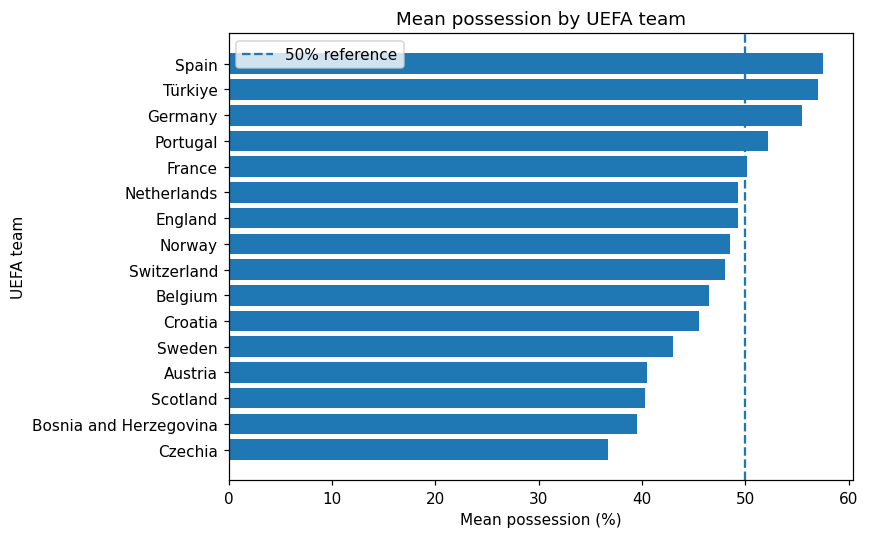

In [15]:
plt.figure(figsize=(8, 5))
plt.barh(team_means['team'], team_means['mean_possession_pct'])
plt.axvline(TEST_VALUE, linestyle='--', linewidth=1.5, label='50% reference')
plt.xlabel('Mean possession (%)')
plt.ylabel('UEFA team')
plt.title('Mean possession by UEFA team')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/possession_uefa_team_means.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Non-parametric check

As another check, I use a Wilcoxon signed-rank test on the 16 team means. It does not rely on a normal distribution in the same way as the t-test.

In [16]:
w_stat, p_wilcoxon = stats.wilcoxon(team_values - TEST_VALUE, alternative='two-sided')
print(f'Wilcoxon statistic = {w_stat:.1f}')
print(f'p value            = {p_wilcoxon:.5f}')
print('Same decision as main test:', (p_wilcoxon < ALPHA) == (p_value < ALPHA))


Wilcoxon statistic = 38.5
p value            = 0.12973
Same decision as main test: True


### 6.3 Why 50% is not a perfect benchmark

A limitation of the question itself is that FIFA separates some possession as **“in contest”**. That means the two teams' reported controlled-possession percentages often add to less than 100%. Therefore 50% is an intuitive benchmark, but not a perfect neutral benchmark for this source.

A possible alternative is to compare a team's controlled possession with half of the non-contested share for that match. However, two FIFA pages contain an impossible `100% in contest` value, so this adjusted result should only be treated as a sensitivity check, not as the main result.

In [17]:
valid_adjusted = uefa[uefa['possession_contested_pct'] < 50].copy()
valid_adjusted['neutral_controlled_pct'] = (100 - valid_adjusted['possession_contested_pct']) / 2
valid_adjusted['difference_from_match_neutral'] = (
    valid_adjusted['possession_pct'] - valid_adjusted['neutral_controlled_pct']
)

t_adj, p_adj = stats.ttest_1samp(valid_adjusted['difference_from_match_neutral'], popmean=0)
print('Rows used:', len(valid_adjusted), 'of', len(uefa))
print(f'Mean difference from match-specific neutral = {valid_adjusted["difference_from_match_neutral"].mean():.3f} percentage points')
print(f't = {t_adj:.4f}, p = {p_adj:.5f}')
print('This sensitivity result changes the interpretation, which shows why the benchmark definition matters.')


Rows used: 78 of 80
Mean difference from match-specific neutral = 3.179 percentage points
t = 2.7123, p = 0.00824
This sensitivity result changes the interpretation, which shows why the benchmark definition matters.


---

## 7. Limitations

1. **Repeated teams.** The same team contributes several match observations, so strict independence is not fully satisfied. The team-level analysis reduces this issue.
2. **50% benchmark.** FIFA includes an “in contest” component, so a fixed 50% is not always the exact neutral share of controlled possession.
3. **Two abnormal source values.** Two FIFA pages report `100% in contest`. They are flagged rather than silently corrected.
4. **One tournament only.** This dataset is the complete 2026 World Cup, not a random sample of all international football. Generalising beyond this tournament should be cautious.
5. **Possession does not equal performance.** A team can have less possession and still create better chances or win the match. This analysis only answers the possession question.

---

## 8. Final summary

| Item | Result |
|---|---|
| UEFA teams | 16 |
| UEFA team-match rows | 80 |
| Mean possession | **48.36%** |
| 95% CI | **46.12% to 50.61%** |
| One-sample t-test | **t(79) = -1.451** |
| p-value | **0.151** |
| Cohen's d | **-0.162 (small)** |
| Normality check | Shapiro-Wilk **p = 0.495** |
| Team-level alternative | **p = 0.128** |
| Wilcoxon alternative | **p = 0.127** |

### Answer to the question

For this tournament, UEFA teams had an average possession of **48.36%**. The main one-sample t-test gave **p = 0.151**, so at the 5% significance level there is **not enough evidence** to say that UEFA teams' mean possession was different from 50%.

The team-level t-test and the Wilcoxon check reach the same decision, which makes the main conclusion reasonably stable. However, the fixed 50% benchmark has an important limitation because FIFA also records possession “in contest”.